1. Look at the big picture.
3. Discover and visualize the data to gain insights.
4. Prepare the data for Machine Learning algorithms.
5. Select a model and train it.
6. Fine-tune your model.
7. Present your solution.
8. Launch, monitor, and maintain your system

framework:
* Supervised learning 
* Regression Task predicting the value 
* univariate regression promblem 
* Batch Learning (is there no continious data, small data and no data changes rapidley)
* RMSE Value metric  

#### 1. Understand Distributions
* Is the target (`price`) skewed? Do we need a log transform?

In [2]:
from pathlib import Path  # ADDED: use portable paths instead of machine-specific paths
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder
from sklearn.model_selection import (train_test_split, KFold, cross_validate, cross_val_score,
                                     cross_val_predict, GridSearchCV)
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Keep the CSV files beside the notebook, or change DATA_DIR to their folder.  
DATA_DIR = Path.cwd()  # PATH FIX: use the current working directory by default  
TRAIN_PATH = DATA_DIR / "challenge1_train.csv"  # PATH FIX: build the training path portably  
TEST_PATH = DATA_DIR / "challenge1_test.csv"  # PATH FIX: build the test path portably  
df = pd.read_csv(TRAIN_PATH)  # PATH FIX: load the training data from the configured path  
df_test = pd.read_csv(TEST_PATH)  # PATH FIX: load the test data from the configured path  

In [4]:
df.columns

Index(['ID', 'price', 'bathrooms', 'bedrooms', 'square_feet', 'latitude',
       'longitude', 'category', 'has_photo', 'state'],
      dtype='str')

Skewness of the price column: 2.71
Skewness of log(price) column: 0.54


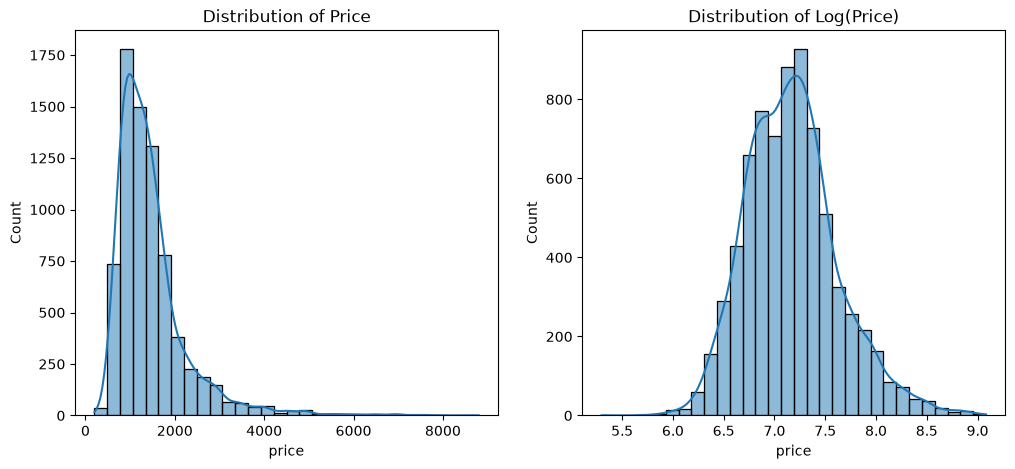

In [5]:
print("Skewness of the price column:", round(df["price"].skew(), 2))
print("Skewness of log(price) column:", round(np.log(df["price"]).skew(), 2))
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df["price"], bins=30, kde=True, ax=ax[0])
ax[0].set_title("Distribution of Price")
sns.histplot(np.log(df["price"]), bins=30, kde=True, ax=ax[1])
ax[1].set_title("Distribution of Log(Price)")
plt.show()

In [6]:
# Observations:
#   * price is strongly right skewed and most rent falls between $1000 to $2000 centered around the logarithmic price of 7.2 which is equivalent to $ 1,340.
# Implications:
#   * Linear regression models such as Linear, Ridge, and Lasso would benefit with a log transform database and tree models don't need it.


#### 2. Find Patterns & Relationships
* Which features correlate with price?

square_feet    0.48
bathrooms      0.44
bedrooms       0.36
latitude       0.04
longitude     -0.19
Name: price, dtype: float64

Median price by state (top 10):
state
HI    2850.0
CA    2325.0
MA    2274.0
WV    2000.0
DC    1966.0
ME    1862.5
NJ    1811.0
WA    1675.0
VT    1512.5
NY    1500.5
Name: price, dtype: float64


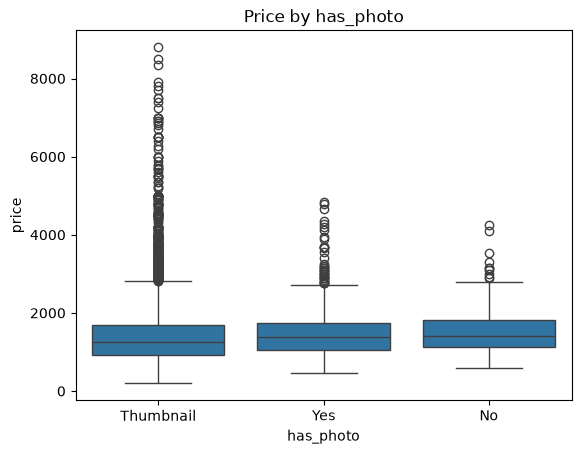

In [7]:
num_cols = ["price", "bathrooms", "bedrooms", "square_feet", "latitude", "longitude"]
print(df[num_cols].corr()["price"].drop("price").sort_values(ascending=False).round(2))

print("\nMedian price by state (top 10):")
print(df.groupby("state")["price"].median().sort_values(ascending=False).head(10))

sns.boxplot(data=df, x="has_photo", y="price")
plt.title("Price by has_photo")
plt.show()

* strongest correlation with price: 
1. square feet r=0.48
2. bathrooms r=0.44
3. bedroms r=0.36
* HI only has a few listing so the median is less reliable than CA 
* latitude and longitude has a weak linear corelation but location can still matter non-linearly which favors tree models. 

In [8]:
print(df.groupby("has_photo")["price"].agg(["median", "mean", "count"]).round(0))

           median    mean  count
has_photo                       
No         1421.0  1589.0    139
Thumbnail  1250.0  1456.0   6566
Yes        1390.0  1501.0    693


the gap between the three categories are small and there are huge class imbalances therefore it better not to rank it but use one hot encoding. 

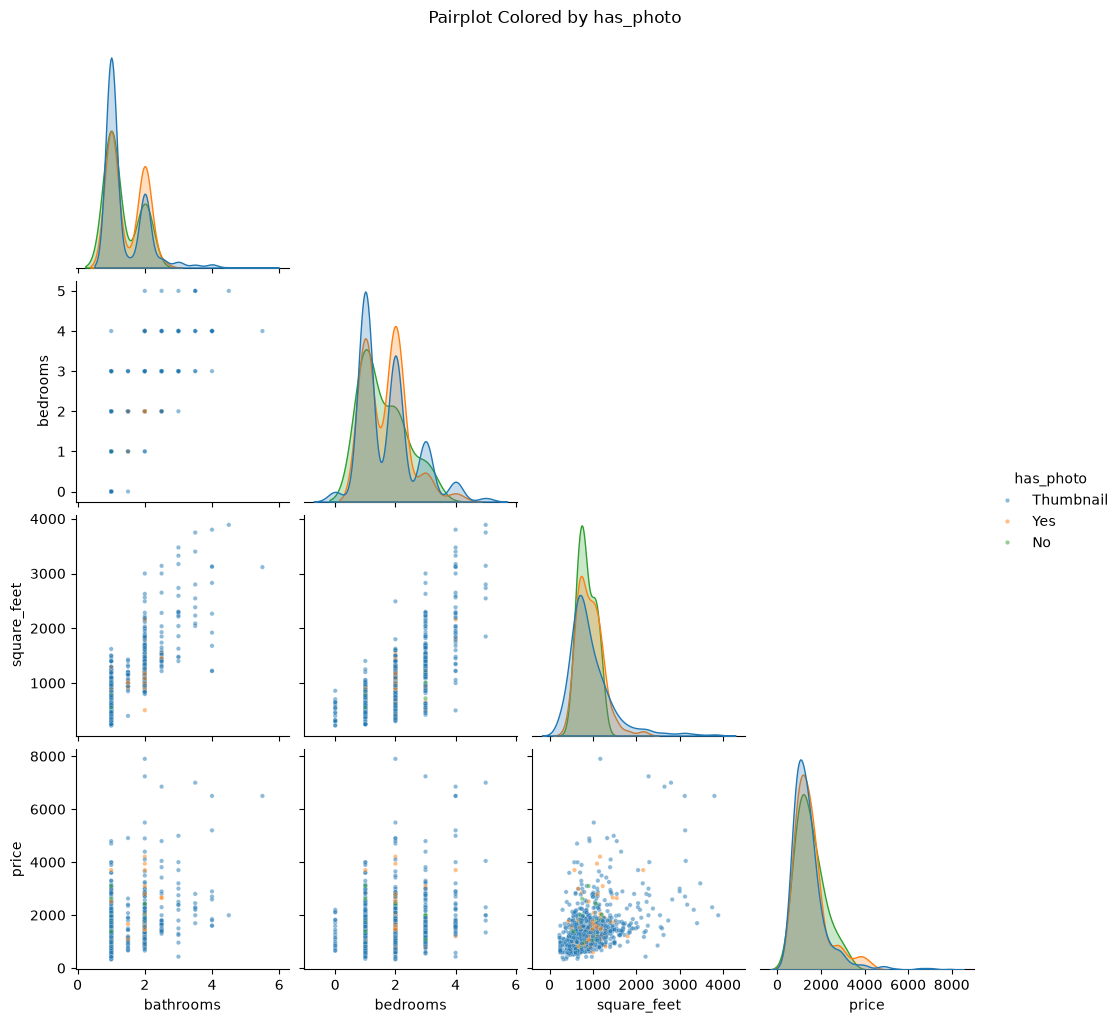

In [9]:
# the graphs shows why we want to use one hot encoding for categorical variables
pairplot_cols = ["bathrooms", "bedrooms", "square_feet", "price"]
sample = df[pairplot_cols + ["has_photo", "state"]].sample(min(1000, len(df)), random_state=42)

sns.pairplot(sample[pairplot_cols + ["has_photo"]], hue="has_photo", corner=True,
             plot_kws=dict(alpha=0.5, s=10), diag_kind="kde", diag_kws=dict(common_norm=False))
plt.suptitle("Pairplot Colored by has_photo", y=1.02)
plt.savefig("pairplot_has_photo.png", bbox_inches="tight")
plt.show()

* bathrooms and bedroms are descrete 
* sizes that move together: square vs bathroms, square vs bedrooms, square vs (bathroom + bedroom)
* heteroscedasticity pattern and right skewness in square feet can be fix with log transformation
* the price diestribution for Thumbnale categories are overlapping together in ever scatter panel. Since has_photo would not have good predictions and has three categories we will use one hot encoding

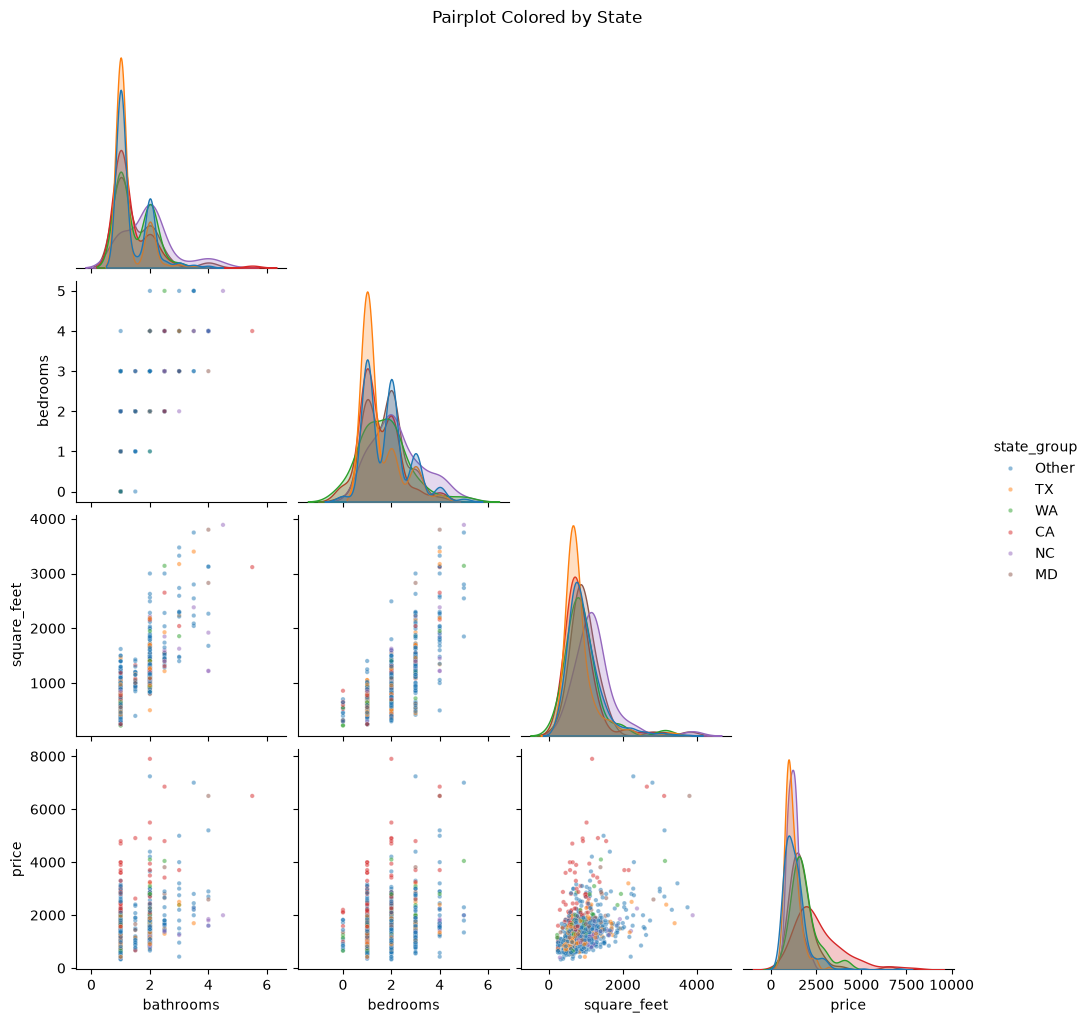

In [10]:
# lets choose  based on the graphs group rare states or target encoding 
top_states = df["state"].value_counts().head(5).index
sample["state_group"] = sample["state"].where(sample["state"].isin(top_states), "Other")

sns.pairplot(sample[pairplot_cols + ["state_group"]], hue="state_group", corner=True,
             plot_kws=dict(alpha=0.5, s=10), diag_kind="kde", diag_kws=dict(common_norm=False))
plt.suptitle("Pairplot Colored by State ", y=1.02)
plt.savefig("pairplot_state.png", bbox_inches="tight")
plt.show()

* States appear to have different price distributions, so state should remain a feature.
* Only about five states (42%) are shown in the plot to keep it readable.
* Plain one-hot encoding performed best for Linear Regression, Ridge, and Random Forest in the encoding comparison. Target encoding performed best for Gradient Boosting, so the best encoding depends on the model.
* The later `make_pre()` function groups rare states; that setup is not the same as plain one-hot encoding.

In [11]:
top5_share = df["state"].value_counts().head(5).sum() / len(df)
print(f"Top 5 states = {top5_share:.0%} of training rows; Other = {1 - top5_share:.0%}")

Top 5 states = 42% of training rows; Other = 58%


### Models

| Model | How it works | Strengths | Limitations | Why it fits this data |
|---|---|---|---|---|
| **Linear Regression** (required) | Finds a simple relationship between the features and price. | Gives us a simple starting point to see how features like square footage, bedrooms, and bathrooms affect price. | May not work well if the features do not have a simple relationship with price. | Gives us a baseline RMSE that we can compare the other models to. |
| **Ridge Regression** (additional) | Uses a linear relationship between the features and price while keeping the feature effects smaller. | Helps when some of the features are related to each other. | Still has the same limits as a linear model. | Some features, like square footage, bedrooms, and bathrooms, are related to each other, so Ridge can help handle that when predicting price. |
| **Lasso Regression** (additional) | Uses a linear relationship and can remove features that are not very useful. | Can help show which features may not contribute much to predicting price. | Still has the same limits as a linear model and may remove useful features. | Lasso can help show which features are less useful for predicting price, such as `has_photo` or states with very few listings. |
| **Decision Tree** (required) | Makes decisions using the features to split the data into different groups. | Can find patterns that are more complicated than a simple linear relationship. | Can become too complicated and overfit the data. | Location can affect price in different ways, so a Decision Tree can find patterns that a simple linear model may miss. |
| **Random Forest** (required) | Uses many Decision Trees together to make a prediction. | Can find more complicated patterns while making more stable predictions. | Can take longer to run and is harder to understand than one tree. | Random Forest can find patterns between the size of a place and its location while making stable price predictions. |
| **Gradient Boosting** (required) | Builds trees one after another, with each tree improving on the previous one. | Can improve prediction accuracy by learning from previous mistakes. | Can overfit and can take longer to train. | Gradient Boosting can help explain price differences that cannot be explained by size alone. |

**Expectation from EDA:** Because price can depend on location in different ways and the errors increase as size increases, tree-based models, especially Random Forest and Gradient Boosting, may have lower RMSE than the linear models. This will be tested using 5-fold cross-validation.

<!-- Removed duplicated model comparison table; the original table is retained in cell 18. -->

In [12]:
num_features = ["bathrooms", "bedrooms", "square_feet", "latitude", "longitude"]
cat_features = ["has_photo", "state"]

X = df[num_features + cat_features]   # ID and category excluded
y = df["price"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
])

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

def evaluate(name, model, X_t, y_t, X_v, y_v):
    model.fit(X_t, y_t)
    train_rmse = root_mean_squared_error(y_t, model.predict(X_t))
    preds = model.predict(X_v)
    rmse = root_mean_squared_error(y_v, preds)
    mae = mean_absolute_error(y_v, preds)
    r2 = r2_score(y_v, preds)
    print(f"{name:<17} Train RMSE: {train_rmse:8.2f} | Val RMSE: {rmse:8.2f} | MAE: {mae:8.2f} | R2: {r2:.2f}")
    return {"Model": name, "Train RMSE": train_rmse, "Val RMSE": rmse, "Val MAE": mae, "Val R2": r2}

models = {
    'LinearRegression': Pipeline([('pre', preprocessor), ('model', LinearRegression())]),
    'Ridge': Pipeline([('pre', preprocessor), ('model', Ridge(alpha=1.0))]),
    'Lasso': Pipeline([('pre', preprocessor), ('model', Lasso(alpha=0.1, max_iter=10000))]),
    'DecisionTree': Pipeline([('pre', preprocessor), ('model', DecisionTreeRegressor(random_state=42))]),
    'RandomForest': Pipeline([('pre', preprocessor), ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))]),
    'GradientBoosting': Pipeline([('pre', preprocessor), ('model', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42))]),
}

results = [evaluate(name, pipe, X_train, y_train, X_val, y_val) for name, pipe in models.items()]

results_df = pd.DataFrame(results).sort_values("Val RMSE").reset_index(drop=True)
results_df["Train/Val gap"] = results_df["Val RMSE"] - results_df["Train RMSE"]
results_df.round(2)

LinearRegression  Train RMSE:   515.14 | Val RMSE:   550.04 | MAE:   349.38 | R2: 0.58
Ridge             Train RMSE:   515.47 | Val RMSE:   551.42 | MAE:   349.64 | R2: 0.58
Lasso             Train RMSE:   515.45 | Val RMSE:   550.99 | MAE:   349.34 | R2: 0.58
DecisionTree      Train RMSE:    39.35 | Val RMSE:   559.31 | MAE:   323.88 | R2: 0.57
RandomForest      Train RMSE:   159.57 | Val RMSE:   453.32 | MAE:   264.74 | R2: 0.72
GradientBoosting  Train RMSE:   405.21 | Val RMSE:   487.96 | MAE:   304.95 | R2: 0.67


,Model,Train RMSE,Val RMSE,Val MAE,Val R2,Train/Val gap
0,RandomForest,159.57,453.32,264.74,0.72,293.74
1,GradientBoosting,405.21,487.96,304.95,0.67,82.75
2,LinearRegression,515.14,550.04,349.38,0.58,34.90
3,Lasso,515.45,550.99,349.34,0.58,35.54
4,Ridge,515.47,551.42,349.64,0.58,35.95
5,DecisionTree,39.35,559.31,323.88,0.57,519.96


In [13]:
state_encoders = {
    "One-hot (all states)": OneHotEncoder(handle_unknown="ignore"),
    "One-hot (rare states grouped)": OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=30),
    "TargetEncoder": TargetEncoder(target_type="continuous", cv=KFold(n_splits=5, shuffle=True, random_state=42)),
}

compare_models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
rows = []
for enc_name, state_enc in state_encoders.items():
    pre = ColumnTransformer([
        ("num", StandardScaler(), num_features),
        ("photo", OneHotEncoder(handle_unknown="ignore"), ["has_photo"]),
        ("state", state_enc, ["state"]),
    ])
    for model_name, model in compare_models.items():
        pipe = Pipeline([("pre", pre), ("model", model)])
        r = cross_validate(pipe, X, y, cv=cv, scoring="neg_root_mean_squared_error", n_jobs=-1)
        rows.append({"State encoding": enc_name, "Model": model_name, "CV Val RMSE": -r["test_score"].mean()})

encoding_df = pd.DataFrame(rows).pivot(index="Model", columns="State encoding", values="CV Val RMSE")
print("Best encoding per model:\n", encoding_df.idxmin(axis=1), "\n")
encoding_df.round(2)

Best encoding per model:
 Model
GradientBoosting           TargetEncoder
LinearRegression    One-hot (all states)
RandomForest        One-hot (all states)
Ridge               One-hot (all states)
dtype: str 



State encoding,One-hot (all states),One-hot (rare states grouped),TargetEncoder
Model,,,
GradientBoosting,461.37,460.95,458.94
LinearRegression,526.82,532.24,537.52
RandomForest,426.71,427.31,432.81
Ridge,526.77,532.21,537.52


The encoding comparison supports keeping plain one-hot encoding as the default for the initial model comparison because it performed best for three of the four models. Gradient Boosting performed best with target encoding in that experiment, so the encoding choice is model-dependent.

##### Visual Comparison 

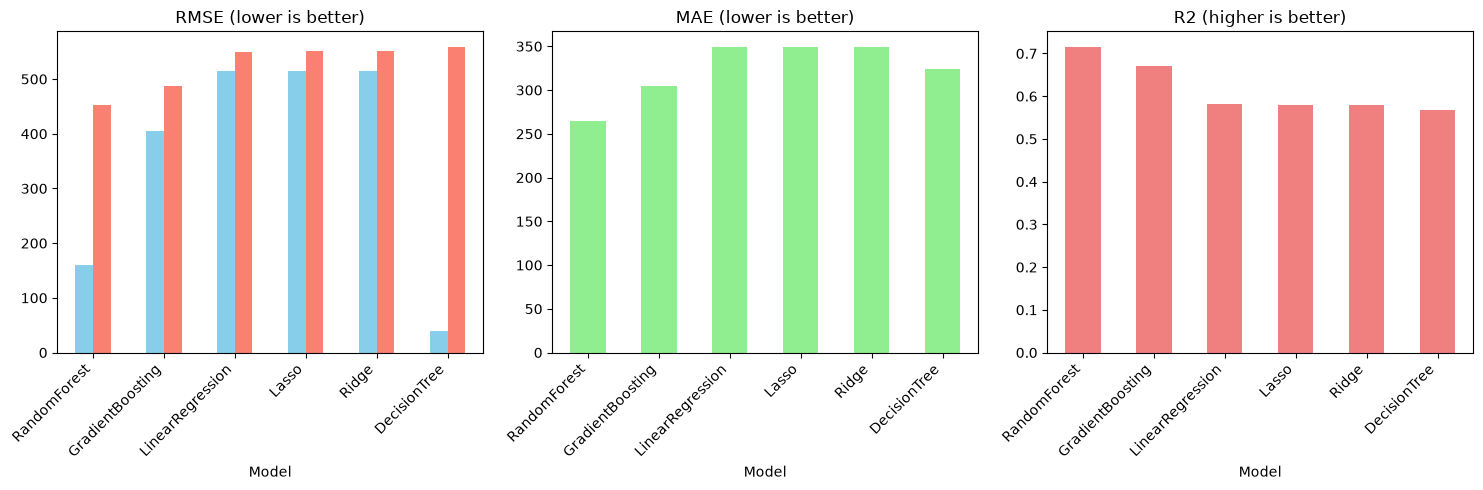

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
results_df.plot.bar(x="Model", y=["Train RMSE", "Val RMSE"], ax=axes[0], title="RMSE Comparison", color=["skyblue", "salmon"], legend=False)
axes[0].set_title("RMSE (lower is better)")
axes[0].set_xticklabels(results_df["Model"], rotation=45, ha="right")
results_df.plot.bar(x="Model", y="Val MAE", ax=axes[1], title="MAE Comparison", color="lightgreen", legend=False)
axes[1].set_title("MAE (lower is better)")
axes[1].set_xticklabels(results_df["Model"], rotation=45, ha="right")
results_df.plot.bar(x="Model", y="Val R2", ax=axes[2], title="R2 Comparison", color="lightcoral", legend=False)
axes[2].set_title("R2 (higher is better)")
axes[2].set_xticklabels(results_df["Model"], rotation=45, ha="right")   

plt.tight_layout()
plt.savefig("model_performance_comparison.png", bbox_inches='tight')
plt.show()



The initial 80/20 holdout comparison selected Random Forest (validation RMSE $453.32) among those baseline models on that one split. Later experiments used five-fold cross-validation and different feature sets and tuned hyperparameters; tuned Gradient Boosting achieved the best reported CV RMSE in those later experiments. These results are not contradictory because they come from different evaluation setups. The CV score is useful for model selection, but it is not a final independent test score.

In [15]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)

best_name = results_df.iloc[0]["Model"]
best_pipe = models[best_name]
print(f"Best model: {best_name} with Val RMSE: {results_df.iloc[0]['Val RMSE']:.2f}")
cv_scores = cross_val_score(best_pipe, X, y, cv=kfold,
                            scoring="neg_root_mean_squared_error", n_jobs=-1)
cv_rmse = -cv_scores
print(f"Cross-validated RMSE: {cv_rmse.mean():.2f} ± {cv_rmse.std():.2f}")
print(f"Individual fold RMSE scores: {cv_rmse.round(2)}")

Best model: RandomForest with Val RMSE: 453.32
Cross-validated RMSE: 426.71 ± 33.68
Individual fold RMSE scores: [454.17 440.71 387.45 465.47 385.76]


In [ ]:
def add_features(d):
    d = d.copy()
    d["total_rooms"] = d["bedrooms"] + d["bathrooms"]
    d["sqft_per_room"] = d["square_feet"] / d["total_rooms"].clip(lower=1)  
    d["bath_per_bed"] = d["bathrooms"] / d["bedrooms"].clip(lower=1)   
    d["is_studio"] = (d["bedrooms"] == 0).astype(int)
    d["log_sqft"] = np.log(d["square_feet"])
    d["lat_plus_lon"] = d["latitude"] + d["longitude"]
    d["lat_minus_lon"] = d["latitude"] - d["longitude"]
    return d

df_fe = add_features(df)
df_test_fe = add_features(df_test)   

In [ ]:

base_num = ["bathrooms", "bedrooms", "square_feet", "latitude", "longitude"]  
new_num = ["total_rooms", "sqft_per_room", "bath_per_bed", "is_studio",  
           "log_sqft", "lat_plus_lon", "lat_minus_lon"] 
cat = ["has_photo", "state"]  

def make_pre(num_cols, state_encoding="grouped_onehot"): 
    state_enc = (OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=30)  
                    if state_encoding == "grouped_onehot" else TargetEncoder(target_type="continuous", cv=KFold(n_splits=5, shuffle=True, random_state=42))) 
    return ColumnTransformer([  
        ("num", StandardScaler(), num_cols),  
        ("photo", OneHotEncoder(handle_unknown="ignore"), ["has_photo"]), 
        ("state", state_enc, ["state"]),  
    ])  

cv = KFold(n_splits=5, shuffle=True, random_state=42) 

setups = {  
    "Original features (grouped one-hot)": (base_num, "grouped_onehot"), 
    "+ engineered features (grouped one-hot)": (base_num + new_num, "grouped_onehot"),  # 
    "+ engineered + target-encoded state": (base_num + new_num, "target"),  
}  

rows = []  
for setup, (num_cols, enc) in setups.items():  
    for mname, m in {"Ridge": Ridge(), "GradientBoosting": GradientBoostingRegressor(random_state=42)}.items():  
        pipe = Pipeline([("pre", make_pre(num_cols, enc)), ("model", m)])  
        r = cross_validate(pipe, df_fe[num_cols + cat], y, cv=cv,  
                           scoring="neg_root_mean_squared_error")  
        rows.append({"Features": setup, "Model": mname, "CV Val RMSE": -r["test_score"].mean()})  

pd.DataFrame(rows).pivot(index="Features", columns="Model", values="CV Val RMSE").round(2) 

In [ ]:
print("Missing values:\\n", df.isnull().sum(), "\\n")  
print("Rows with price <= 0:", (df["price"] <= 0).sum()) 
print("Rows with square_feet <= 0:", (df["square_feet"] <= 0).sum())  
print("Studios (bedrooms = 0):", (df["bedrooms"] == 0).sum())  
print("Duplicate rows (excluding ID):", df.drop(columns="ID").duplicated().sum())  
print("\\ncategory counts:\\n", df["category"].value_counts())  

duplicate_features = df.drop(columns=["ID", "price"], errors="ignore") 
duplicate_mask = duplicate_features.duplicated(keep=False)  
duplicate_groups = duplicate_features[duplicate_mask].value_counts().rename("rows_in_group").reset_index()  
print("Rows in repeated predictor patterns:", int(duplicate_mask.sum()))  
print("Repeated predictor groups:", len(duplicate_groups)) 
display(duplicate_groups.head(10))  


* Price outliers were **not** removed: no impossible values were identified in the checks above, and RMSE penalizes large prediction errors.
* Tree-based models may capture nonlinear patterns, but their scores do not prove that outlier influence has been eliminated.
* A log-target comparison is added below. It evaluates predictions after converting them back to the original price scale, so the RMSE remains comparable in dollars.

In [ ]:
# Compare original-price and log1p(price) targets using the same folds and predictors.  
from sklearn.compose import TransformedTargetRegressor  
log_target_models = {  
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1), 
    "GradientBoosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42), 
}  
log_target_rows = []  
for model_name, base_model in log_target_models.items():  
    base_pipe = Pipeline([("pre", preprocessor), ("model", base_model)])  
    for target_name, estimator in [("Original price", base_pipe), ("log1p target", TransformedTargetRegressor(regressor=base_pipe, func=np.log1p, inverse_func=np.expm1))]:  
        scores = cross_val_score(estimator, X, y, cv=kfold, scoring="neg_root_mean_squared_error", n_jobs=-1)  
        log_target_rows.append({"Model": model_name, "Target": target_name, "CV RMSE (dollars)": -scores.mean(), "CV RMSE SD": scores.std()})  
log_target_results = pd.DataFrame(log_target_rows).sort_values("CV RMSE (dollars)").reset_index(drop=True)  
display(log_target_results.round(2))  


In [19]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
rmse_scoring = "neg_root_mean_squared_error"

models_to_tune = {
    "DecisionTree": (DecisionTreeRegressor(random_state=42), {
        "model__max_depth": [4, 6, 8, 10, 15, None],
        "model__min_samples_leaf": [1, 5, 10, 20],
        "model__min_samples_split": [2, 10, 20],
    }),
    "RandomForest": (RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1), {
        "model__max_depth": [None, 20],
        "model__min_samples_leaf": [1, 3, 5],
        "model__max_features": [0.5, 1.0],
    }),
    "GradientBoosting": (GradientBoostingRegressor(random_state=42), {
        "model__n_estimators": [200, 400],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [3, 4, 5],
        "model__min_samples_leaf": [1, 10],
    }),
    "Ridge": (Ridge(), {"model__alpha": np.logspace(-3, 3, 13)}),
    "Lasso": (Lasso(max_iter=10000), {"model__alpha": np.logspace(-3, 2, 11)}),
}

grid_searches = {}
tuning_results = []

for model_name, (base_model, param_grid) in models_to_tune.items():
    pipeline = Pipeline([("pre", preprocessor), ("model", base_model)])

    # untuned baseline
    default_cv_results = cross_validate(pipeline, X, y, cv=kfold, scoring=rmse_scoring, n_jobs=-1)
    default_rmse = -default_cv_results["test_score"].mean()

    # grid search
    grid_search = GridSearchCV(pipeline, param_grid, cv=kfold, scoring=rmse_scoring,
                               return_train_score=True, n_jobs=-1)
    grid_search.fit(X, y)
    best_index = grid_search.best_index_
    grid_searches[model_name] = grid_search

    tuning_results.append({
        "Model": model_name,
        "Default CV RMSE": default_rmse,
        "Tuned Train RMSE": -grid_search.cv_results_["mean_train_score"][best_index],
        "Tuned CV RMSE": -grid_search.best_score_,
        "CV RMSE SD": grid_search.cv_results_["std_test_score"][best_index],
        "Best params": {param.replace("model__", ""): value
                        for param, value in grid_search.best_params_.items()},
    })
    print(f"{model_name:<17} default {default_rmse:8.2f} -> tuned {-grid_search.best_score_:8.2f}")

tuning_results_df = pd.DataFrame(tuning_results).sort_values("Tuned CV RMSE").reset_index(drop=True)
tuning_results_df["Improvement"] = tuning_results_df["Default CV RMSE"] - tuning_results_df["Tuned CV RMSE"]
tuning_results_df["Train/CV gap"] = tuning_results_df["Tuned CV RMSE"] - tuning_results_df["Tuned Train RMSE"]
pd.set_option("display.max_colwidth", None)
tuning_results_df.round(2)

DecisionTree      default   555.96 -> tuned   483.22
RandomForest      default   423.33 -> tuned   413.61
GradientBoosting  default   461.37 -> tuned   392.90
Ridge             default   526.77 -> tuned   526.72
Lasso             default   530.73 -> tuned   526.72


,Model,Default CV RMSE,Tuned Train RMSE,Tuned CV RMSE,CV RMSE SD,Best params,Improvement,Train/CV gap
0,GradientBoosting,461.37,261.83,392.90,23.63,"{'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 10, 'n_estimators': 400}",68.47,131.07
1,RandomForest,423.33,177.38,413.61,29.60,"{'max_depth': 20, 'max_features': 0.5, 'min_samples_leaf': 1}",9.72,236.23
2,DecisionTree,555.96,373.00,483.22,30.29,"{'max_depth': 15, 'min_samples_leaf': 5, 'min_samples_split': 20}",72.74,110.22
3,Ridge,526.77,521.08,526.72,25.59,{'alpha': 0.31622776601683794},0.05,5.64
4,Lasso,530.73,521.08,526.72,25.57,{'alpha': 0.03162277660168379},4.00,5.64


In [20]:
gb_pipeline = Pipeline([("pre", preprocessor), ("model", GradientBoostingRegressor(random_state=42))])

gb_regularized_grid = {
    "model__n_estimators": [400, 800],
    "model__learning_rate": [0.05],
    "model__max_depth": [5],
    "model__min_samples_leaf": [10, 20],
    "model__subsample": [0.8, 1.0],
    "model__max_features": [0.5, 1.0],
}

gb_regularized_search = GridSearchCV(gb_pipeline, gb_regularized_grid, cv=kfold, scoring=rmse_scoring,
                                     return_train_score=True, n_jobs=-1)
gb_regularized_search.fit(X, y)

best_index = gb_regularized_search.best_index_
regularized_train_rmse = -gb_regularized_search.cv_results_["mean_train_score"][best_index]
regularized_cv_rmse = -gb_regularized_search.best_score_

print("Best params:", {k.replace("model__", ""): v for k, v in gb_regularized_search.best_params_.items()})
print(f"Train RMSE: {regularized_train_rmse:.2f} | CV RMSE: {regularized_cv_rmse:.2f} | "
      f"Gap: {regularized_cv_rmse - regularized_train_rmse:.2f}")
print("Previous best: Train 261.83 | CV 392.90 | Gap 131.07")

Best params: {'learning_rate': 0.05, 'max_depth': 5, 'max_features': 0.5, 'min_samples_leaf': 10, 'n_estimators': 800, 'subsample': 1.0}
Train RMSE: 269.54 | CV RMSE: 389.79 | Gap: 120.25
Previous best: Train 261.83 | CV 392.90 | Gap 131.07


In [21]:
# final-model selection: use the engineered-feature model because it achieved the best CV RMSE.
fe_num_features = num_features + ["total_rooms", "sqft_per_room", "bath_per_bed", "is_studio",
                                  "log_sqft", "lat_plus_lon", "lat_minus_lon"]
fe_preprocessor = ColumnTransformer([
    ("num", StandardScaler(), fe_num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
])
X_fe = df_fe[fe_num_features + cat_features]

gb_fe_search = GridSearchCV(
    Pipeline([("pre", fe_preprocessor), ("model", GradientBoostingRegressor(random_state=42))]),
    gb_regularized_grid, cv=kfold, scoring=rmse_scoring, return_train_score=True, n_jobs=-1)
gb_fe_search.fit(X_fe, y)
print(f"With engineered features: CV RMSE {-gb_fe_search.best_score_:.2f}  (without: 389.79)")
print("Best params:", {k.replace("model__", ""): v for k, v in gb_fe_search.best_params_.items()})

With engineered features: CV RMSE 385.05  (without: 389.79)
Best params: {'learning_rate': 0.05, 'max_depth': 5, 'max_features': 0.5, 'min_samples_leaf': 10, 'n_estimators': 800, 'subsample': 1.0}


**Cross-validation note:** The engineered-feature Gradient Boosting hyperparameters were selected by `GridSearchCV` using the full training dataset. The later out-of-fold predictions hold out each fold when fitting the model, but the hyperparameter choice has already used all training targets. Therefore, these plots are useful diagnostics, not a fully independent estimate of the complete model-selection process. A nested cross-validation procedure would be needed for that stronger estimate.

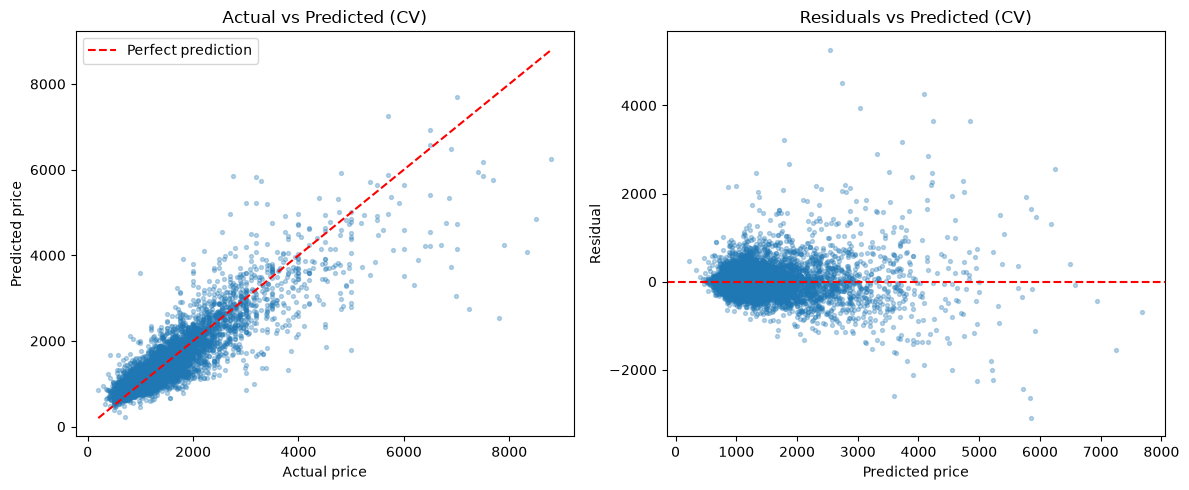

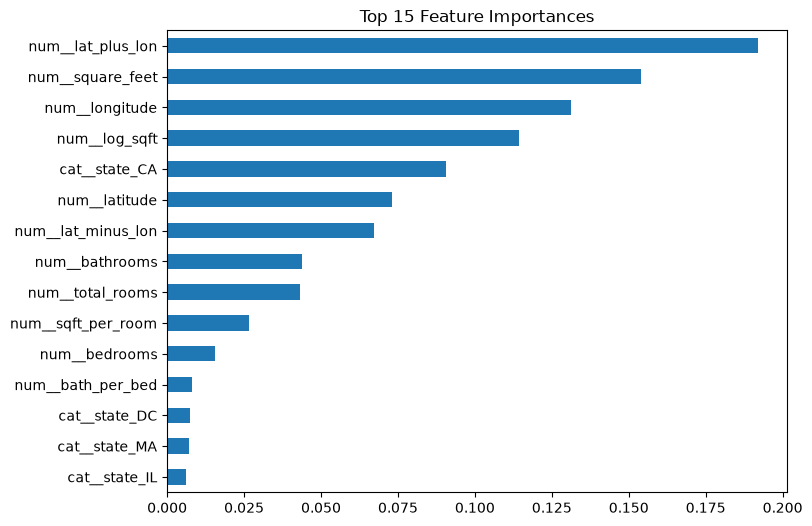

In [22]:
#final_model and X_fe now use the same engineered-feature pipeline.
# Use the tuned engineered-feature pipeline and make sure it is defined before OOF CV
final_model = gb_fe_search.best_estimator_
final_model.fit(X_fe, y)

oof_predictions = cross_val_predict(final_model, X_fe, y, cv=kfold, n_jobs=-1)
residuals = y - oof_predictions

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(y, oof_predictions, alpha=0.3, s=8)
ax[0].plot([y.min(), y.max()], [y.min(), y.max()], color="red", linestyle="--", label="Perfect prediction")
ax[0].set(xlabel="Actual price", ylabel="Predicted price", title="Actual vs Predicted (CV)")
ax[0].legend()
ax[1].scatter(oof_predictions, residuals, alpha=0.3, s=8)
ax[1].axhline(0, color="red", linestyle="--")
ax[1].set(xlabel="Predicted price", ylabel="Residual", title="Residuals vs Predicted (CV)")
plt.tight_layout()
plt.show()

feature_names = final_model.named_steps["pre"].get_feature_names_out()
importances = pd.Series(final_model.named_steps["model"].feature_importances_, index=feature_names)
importances.sort_values(ascending=False).head(15).plot(kind="barh", figsize=(8, 6), title="Top 15 Feature Importances")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
# Generate final predictions using the same engineered features as the selected final model.
X_test_fe = df_test_fe[fe_num_features + cat_features]

# final_model is already the tuned engineered-feature Gradient Boosting pipeline.
final_predictions = final_model.predict(X_test_fe)

submission = pd.DataFrame({
    "ID": df_test["ID"],
    "price": final_predictions
})

assert len(submission) == len(df_test)
assert submission["ID"].is_unique
assert submission["price"].notna().all()

submission.to_csv("predictions.csv", index=False)

print(f"Saved predictions.csv with {len(submission):,} predictions.")
display(submission.head())


Saved predictions.csv with 2,467 predictions.


,ID,price
0,1,1265.294535
1,4,2087.184599
2,9,680.344789
3,11,725.526645
4,13,656.465787
